# Spotify Track Popularity Analysis - Group 1
**Team Members:** Jonathan Dong, Daniel Fu, Charlotte Stroff

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [57]:
df = pd.read_csv('spotify_dataset.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Data Cleaning & Feature Selection**
We removed non-predictive identifiers (*names*, *IDs*), dropped missing values, and converted the explicit boolean into an integer to focus strictly on the numeric data. For our baseline model, we selected 12 core audio features (*tempo*, *energy*, *danceability*, etc.) to predict popularity.

In [58]:
# Drop useless columns
df = df.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists'])

# Convert 'explicit' boolean to int
df['explicit'] = df['explicit'].astype(int)

# Drop na rows
df = df.dropna()

# Define target
y = df['popularity']

# Base numeric features
base_features = [
    'danceability', 'energy', 'tempo', 'valence',
    'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'duration_ms',
    'explicit', 'mode'
]

X = df[base_features]

**Data Splitting & Scaling**
To evaluate our models fairly, we split the dataset into training (80%) and testing (20%) sets. We then applied a StandardScaler to normalize the feature ranges, fitting it only on the training data to prevent data leakage before transforming both sets.

In [59]:
# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features to have mean = 0 and variance = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Baseline Linear Regression**
To establish a performance baseline/benchmark, we fit a standard Linear Regression model using our 12 scaled base features.

In [60]:
# Baseline Linear Regression
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)

# Calculate MSE
errors = y_test - y_pred_baseline
squared_errors = errors ** 2
mse = np.mean(squared_errors)

print("BASELINE MODEL")
print("MSE:", mse)
print("R^2:", r2_score(y_test, y_pred_baseline))

BASELINE MODEL
MSE: 482.50389075566636
R^2: 0.022244011556364796


**Interpretation of Baseline Results**
The baseline model yielded an $R^2$ of approximately 0.022, which indicates that only 2.2% of the variance in a track's popularity is explained by its base audio features when applying a "one-size-fits-all" linear model. This extremely low score confirms our initial hypothesis that raw audio metrics alone are insufficient to predict popularity, likely due to differences in audience behavior across different genres.

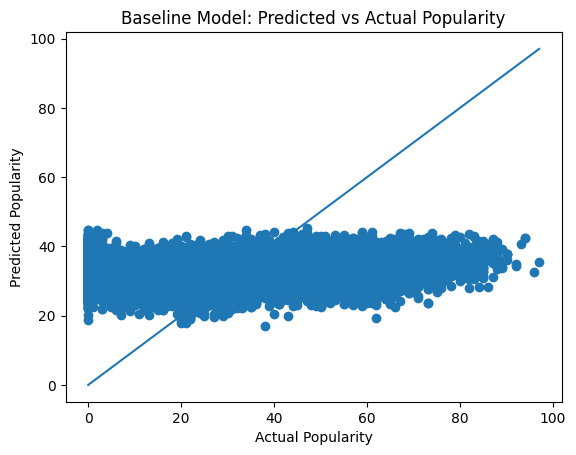

In [61]:
plt.figure()
plt.scatter(y_test, y_pred_baseline)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_baseline.min())
max_val = max(y_test.max(), y_pred_baseline.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Baseline Model: Predicted vs Actual Popularity")

plt.show()

**Figure 1: Visualizing Model Performance**
The scatter plot visually confirms the poor performance indicated by our $R^2$ score, as the predictions form a dense horizontal band rather than clustering along the diagonal reference line. This indicates that the model struggles to capture the variance in the data, mostly predicting a value close to the mean popularity for almost every track, and completely fails to predict the tracks with an actual popularity of 0.

**Polynomial & Interaction Features**
Given the baseline model's low $R^2$, we expanded our feature set by generating second-degree polynomial and interaction terms to test whether the relationship between audio features and popularity is non-linear or dependent on specific feature combinations.

In [62]:
# Adding polynomial and interaction features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [63]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("POLY MODEL")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R^2:", r2_score(y_test, y_pred_poly))
feature_names = poly.get_feature_names_out(base_features)
# print(feature_names)

POLY MODEL
MSE: 464.3455485396334
R^2: 0.059040456480631276


**Interpretation of Polynomial Regression Results**
By introducing second-degree polynomial and interaction terms, our $R^2$ improved from 0.022 to approximately 0.059, and the Mean Squared Error (MSE) decreased as well. This confirms that non-linear relationships and feature interactions (e.g., the combined effect of danceability and energy) hold more predictive value than individual features alone. However, this improvement is only marginal, and this massive expansion of features also increases the risk of overfitting.

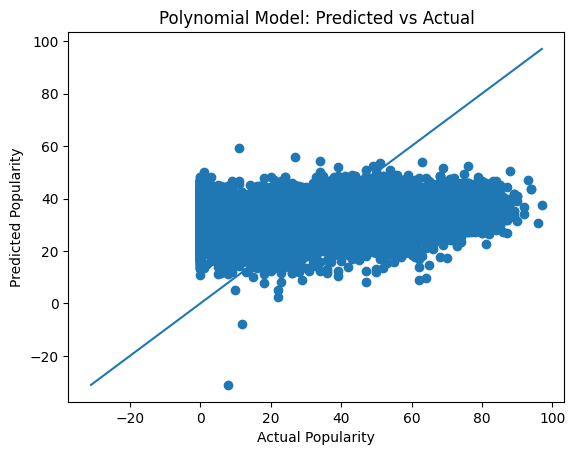

In [64]:
plt.figure()
plt.scatter(y_test, y_pred_poly)

min_val = min(y_test.min(), y_pred_poly.min())
max_val = max(y_test.max(), y_pred_poly.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Polynomial Model: Predicted vs Actual")
plt.show()

**Figure 2: Visualizing Polynomial Model Performance**
Similar to the baseline model, the scatter plot for the polynomial regression still shows a dense horizontal band rather than aligning tightly along the diagonal reference line, with just the vertical spread of predictions slightly increasing (reflecting the marginal improvement in $R^2$). However, there is a significant new issue in that the model is now predicting negative popularity scores for certain tracks, which is impossible. This likely indicates overfitting from the massive expansion of features, which causes the model to use coefficients that mostly capture noise, making the predictions more unstable and less based on a clear trend, resulting in outlier values such as negative scores.

In [65]:
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_poly, y_train)

y_pred_lasso = lasso.predict(X_test_poly)

print("LASSO MODEL")
print("Alpha:", lasso.alpha_)
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R^2:", r2_score(y_test, y_pred_lasso))

LASSO MODEL
Alpha: 0.006208448621826416
MSE: 464.3594491295137
R^2: 0.059012288034202665


**Interpretation of Regularization Results**
The Lasso model selected an optimal alpha of roughly 0.0062, which yields an $R^2$ of approximately 0.059 once again. This is basically the same score as our unregularized polynomial model, indicating that although Lasso applied penalties and reduced overfitting by functioning as an automated feature selector, it did not increase the model's overall predictive power. This plateau indicates that we have maximized the potential of a global linear model on this dataset, which confirms our core hypothesis that we must segment our data by genre to really attempt to predict accurately at all.

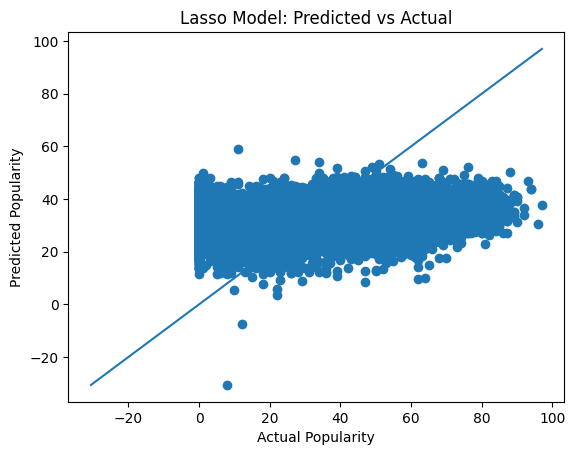

In [66]:
plt.figure()
plt.scatter(y_test, y_pred_lasso)

min_val = min(y_test.min(), y_pred_lasso.min())
max_val = max(y_test.max(), y_pred_lasso.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Lasso Model: Predicted vs Actual")
plt.show()

**Figure 3: Visualizing Lasso Regularization Predictions**
Looking at the scatter plot, the predictions are essentially identical to the unregularized polynomial model, including the fact that there are still negative popularity scores. This is likely because Lasso selected an optimal alpha of roughly 0.0062. This tiny alpha indicates that the model could not find a way to apply a stronger penalty without further reducing the $R^2$ of approximately 0.059. This visualization and plateau serve as definitive proof that we cannot really get any further with this global linear model.

In [67]:
alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_poly, y_train)

y_pred_ridge = ridge.predict(X_test_poly)

print("\nRIDGE MODEL")
print("Best alpha:", ridge.alpha_)
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R^2:", r2_score(y_test, y_pred_ridge))


RIDGE MODEL
Best alpha: 568.9866029018293
MSE: 464.33457220955916
R^2: 0.05906269914575135


**Applying Ridge Regression**
To ensure we thoroughly explored regularization, we also tested a Ridge Regression model, which, unlike Lasso, selected a massive optimal alpha of approximately 569. However, despite applying this heavy penalty to the coefficients, the $R^2$ still remained at roughly 0.059. This means that regardless of the regularization technique or penalty strength used, the predictive power of a global linear model is effectively stuck at a very low level on this dataset.

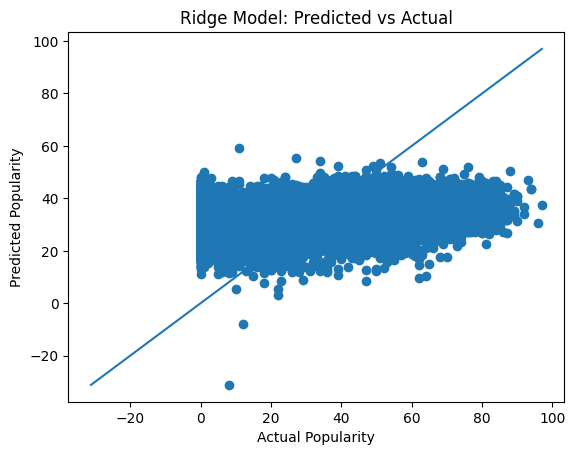

In [68]:
plt.figure()
plt.scatter(y_test, y_pred_ridge)

min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Ridge Model: Predicted vs Actual")
plt.show()

**Figure 4: Visualizing Ridge Regularization Predictions**
Despite testing a massive optimal alpha of approximately 569 in our Ridge model, the $R^2$ remained at 0.059, and the impossible negative predictions still exist. It is significant that both a tiny penalty (Lasso) and a massive penalty (Ridge) produced identical results, which proves that the issue is not the regularization strength, but rather the underlying structure of the dataset itself. This indicates that the relationships between audio features and popularity are too contradictory to be captured by a global linear regression.

**Final Conclusion: Part 1 Analysis**
No matter what we do, the "one model fits all" assumption, as we expected, does not work at all, since the highest $R^2$ we achieved is approximately 0.059. We are now moving onto stage 2 of our project: splitting the data into genres and building separate models for each. We expect these specialized models to perform significantly better by capturing the unique audio-feature relationships specific to each musical style.